# Dataset Understanding & Target Validation

## Setup

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

COLORS = {
    "red":      "#E10600",
    "charcoal": "#1F1F27",
    "slate":    "#5B5F66",
    "cream":    "#F7F4EF",
    "panel":    "#FFFFFF",
    "grid":     "#E4E0DA",
    "accent":   "#0090D4",
}
COMPOUND_COLORS = {
    "SOFT":         "#DA291C",
    "MEDIUM":       "#F5C518",
    "HARD":         "#B4B4B4",
    "INTERMEDIATE": "#43B02A",
    "WET":          "#0067AD",
}

sns.set_theme(style="white", context="notebook")
mpl.rcParams.update({
    "figure.facecolor":     COLORS["cream"],
    "axes.facecolor":       COLORS["panel"],
    "savefig.facecolor":    COLORS["cream"],
    "savefig.dpi":          150,
    "savefig.bbox":         "tight",
    "savefig.pad_inches":   0.35,
    "axes.edgecolor":       COLORS["slate"],
    "axes.linewidth":       0.8,
    "axes.labelcolor":      COLORS["charcoal"],
    "axes.titlecolor":      COLORS["charcoal"],
    "axes.titlesize":       16,
    "axes.titleweight":     "bold",
    "axes.titlelocation":   "left",
    "axes.titlepad":        38,
    "axes.labelsize":       11,
    "axes.labelweight":     "semibold",
    "axes.labelpad":        8,
    "axes.spines.top":      False,
    "axes.spines.right":    False,
    "xtick.color":          COLORS["charcoal"],
    "ytick.color":          COLORS["charcoal"],
    "xtick.labelsize":      10,
    "ytick.labelsize":      10,
    "grid.color":           COLORS["grid"],
    "grid.linewidth":       0.8,
    "font.family":          "DejaVu Sans",
    "font.size":            11,
    "legend.frameon":       False,
})

def add_subtitle(ax, text):
    ax.text(0, 1.02, text, transform=ax.transAxes,
            ha="left", va="bottom",
            color=COLORS["slate"], fontsize=10.5)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

NB_DIR = Path.cwd()
# Walk up until we find the project root (the dir that contains data/ or the CSV).
PROJECT_ROOT = NB_DIR
for _ in range(4):
    if (PROJECT_ROOT / "data").exists() or (PROJECT_ROOT / "f1_strategy_dataset_v4.csv").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

# Input CSV may live at the project root OR inside data/.
for candidate in (PROJECT_ROOT / "data" / "f1_strategy_dataset_v4.csv",
                  PROJECT_ROOT / "f1_strategy_dataset_v4.csv"):
    if candidate.exists():
        DATA_PATH = candidate
        break
else:
    raise FileNotFoundError("f1_strategy_dataset_v4.csv not found in project root or data/")

OUT_DATA_DIR  = PROJECT_ROOT / "data"
FIG_DIR       = PROJECT_ROOT / "reports" / "figures"
OUT_DATA_PATH = OUT_DATA_DIR / "f1_strategy_dataset_v4_validated.csv"

OUT_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load & Inspect the Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print()
print("Columns:")
for c in df.columns:
    print(" -", c)


Shape: (101371, 16)

Columns:
 - Driver
 - LapNumber
 - Compound
 - Stint
 - TyreLife
 - Position
 - LapTime (s)
 - Race
 - Year
 - LapTime_Delta
 - Cumulative_Degradation
 - PitStop
 - PitNextLap
 - RaceProgress
 - Normalized_TyreLife
 - Position_Change


In [3]:
print("Dtypes:")
print(df.dtypes)


Dtypes:
Driver                        str
LapNumber                   int64
Compound                      str
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
Race                          str
Year                        int64
LapTime_Delta             float64
Cumulative_Degradation    float64
PitStop                     int64
PitNextLap                  int64
RaceProgress              float64
Normalized_TyreLife       float64
Position_Change           float64
dtype: object


In [4]:
df.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [5]:
df.tail()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
101366,ZHO,52,HARD,3,29.0,12,103.373,United States Grand Prix,2022,26.850,-90.264,0,0,0.722222,0.852941,2.0
101367,ZHO,53,HARD,3,30.0,13,105.200,United States Grand Prix,2022,27.061,-88.437,0,0,0.736111,0.882353,1.0
101368,ZHO,54,HARD,3,31.0,13,104.102,United States Grand Prix,2022,27.149,-89.535,0,0,0.750000,0.911765,0.0
101369,ZHO,55,HARD,3,32.0,14,103.812,United States Grand Prix,2022,4.428,-89.825,0,0,0.763889,0.941176,-1.0
101370,ZHO,56,HARD,3,33.0,14,103.881,United States Grand Prix,2022,21.390,-89.756,0,1,0.777778,0.970588,4.0


In [6]:
missing = df.isna().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() else "  (none)")
print()
print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
Compound    66
dtype: int64

Duplicate rows: 0


In [7]:
print("Unique races  :", df["Race"].nunique())
print("Unique drivers:", df["Driver"].nunique())
print("Year range    :", int(df["Year"].min()), "→", int(df["Year"].max()))
print("Years present :", sorted(df["Year"].unique().tolist()))


Unique races  : 28
Unique drivers: 31
Year range    : 2022 → 2025
Years present : [2022, 2023, 2024, 2025]


In [8]:
df.describe(include=[np.number])

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000
mean,30.444841,2.046394,14.549339,9.759132,92.587188,2023.589685,-0.203891,-29.550051,0.251581,0.254797,0.432618,0.386521,-0.004636
std,18.146942,0.948797,10.313385,5.406456,33.231414,1.098518,45.344910,70.235759,0.433924,0.435749,0.258129,0.259906,3.912725
min,1.000000,1.000000,1.000000,1.000000,67.012000,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,82.021000,2023.000000,-7.253000,-51.054500,0.000000,0.000000,0.210526,0.172414,-2.000000
50%,30.000000,2.000000,13.000000,10.000000,91.167000,2024.000000,-0.027000,-21.678000,0.000000,0.000000,0.421053,0.333333,0.000000
75%,45.000000,3.000000,20.000000,14.000000,99.356000,2025.000000,5.705000,-3.725500,1.000000,1.000000,0.631579,0.562500,2.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000


## 2. Analyze the Existing Target `PitNextLap`

In [9]:
vc = df["PitNextLap"].value_counts(dropna=False).sort_index()
pos = int(vc.get(1, 0))
neg = int(vc.get(0, 0))
total = pos + neg
pos_rate = pos / total if total else float("nan")
imbalance = neg / pos if pos else float("inf")

print("Value counts:")
print(vc)
print()
print(f"Positive (pit next lap)     : {pos:>7,}")
print(f"Negative (no pit next lap)  : {neg:>7,}")
print(f"Positive rate               : {pos_rate:.4%}")
print(f"Imbalance ratio (neg / pos) : {imbalance:.1f} : 1")
print(f"Missing values in target    : {int(df['PitNextLap'].isna().sum())}")


Value counts:
PitNextLap
0    75542
1    25829
Name: count, dtype: int64

Positive (pit next lap)     :  25,829
Negative (no pit next lap)  :  75,542
Positive rate               : 25.4797%
Imbalance ratio (neg / pos) : 2.9 : 1
Missing values in target    : 0


In [10]:
by_race = (df.groupby("Race")["PitNextLap"]
             .agg(pits="sum", laps="count", pit_rate="mean")
             .sort_values("pit_rate", ascending=False))
by_race


,pits,laps,pit_rate
Race,,,
Pre-Season Track Session,406,773,0.525226
Chinese Grand Prix,969,2072,0.467664
Pre-Season Test,384,918,0.418301
Monaco Grand Prix,1923,5164,0.372386
Saudi Arabian Grand Prix,1267,3430,0.369388
Belgian Grand Prix,1125,3151,0.357030
Bahrain Grand Prix,1448,4415,0.327973
French Grand Prix,306,945,0.323810
Spanish Grand Prix,1536,5054,0.303918


In [11]:
by_driver = (df.groupby("Driver")["PitNextLap"]
               .agg(pits="sum", laps="count", pit_rate="mean")
               .sort_values("pit_rate", ascending=False))
print("Top 10 drivers by pit rate:")
print(by_driver.head(10))
print()
print("Bottom 10 drivers by pit rate:")
print(by_driver.tail(10))


Top 10 drivers by pit rate:
        pits  laps  pit_rate
Driver                      
HAD      523  1369  0.382031
VET      383  1022  0.374755
LAT      356  1061  0.335533
ANT      420  1315  0.319392
MSC      332  1060  0.313208
BOR      387  1253  0.308859
DOO       82   270  0.303704
STR     1455  5005  0.290709
BEA      450  1555  0.289389
LAW      552  1936  0.285124

Bottom 10 drivers by pit rate:
        pits  laps  pit_rate
Driver                      
RIC      637  2645  0.240832
ALB     1110  4642  0.239121
BOT      834  3658  0.227993
MAG      817  3596  0.227197
NOR     1215  5436  0.223510
HUL      901  4033  0.223407
PER      801  3671  0.218197
ZHO      782  3613  0.216441
SAR      280  1941  0.144256
DEV       17   661  0.025719


In [12]:
by_compound = (df.groupby("Compound")["PitNextLap"]
                 .agg(pits="sum", laps="count", pit_rate="mean")
                 .sort_values("pit_rate", ascending=False))
by_compound


,pits,laps,pit_rate
Compound,,,
HARD,14475,44967,0.321903
SOFT,3047,12744,0.239093
INTERMEDIATE,1082,5556,0.194744
MEDIUM,7180,37639,0.190760
WET,7,399,0.017544


In [13]:
by_stint = (df.groupby("Stint")["PitNextLap"]
              .agg(pits="sum", laps="count", pit_rate="mean"))
by_stint


,pits,laps,pit_rate
Stint,,,
1,3457,31942,0.108227
2,15240,41672,0.365713
3,6052,20901,0.289556
4,997,5250,0.189905
5,78,1258,0.062003
6,4,289,0.013841
7,1,40,0.025000
8,0,19,0.000000


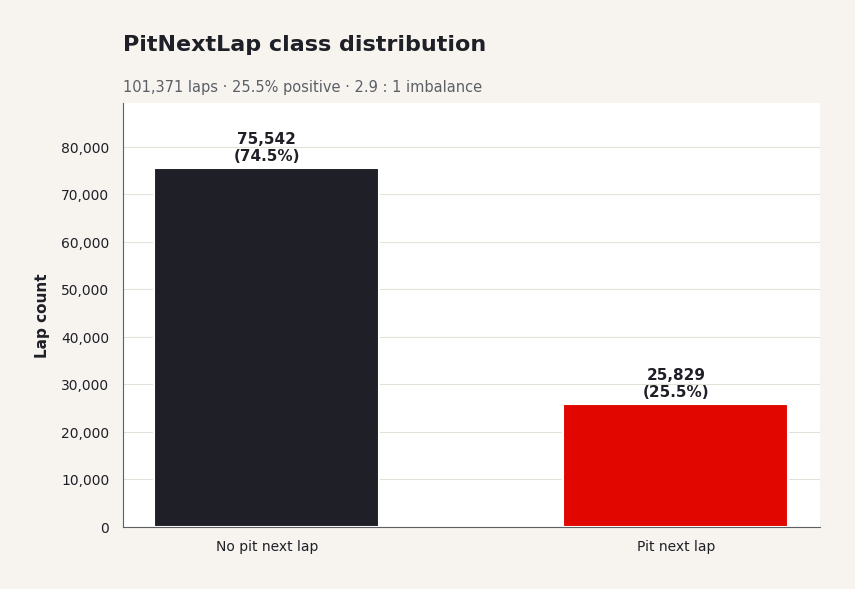

Saved: /Users/hiba/Documents/Projects/Experiments/Race Strategist/reports/figures/pitnextlap_distribution.png


In [14]:
counts   = df["PitNextLap"].value_counts().sort_index()
pct      = counts / counts.sum()
labels   = ["No pit next lap", "Pit next lap"]
palette  = [COLORS["charcoal"], COLORS["red"]]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(labels, counts.values, color=palette, width=0.55,
              edgecolor="white", linewidth=1.5)
for b, v, p in zip(bars, counts.values, pct.values):
    ax.text(b.get_x() + b.get_width() / 2, v + counts.max() * 0.012,
            f"{v:,}\n({p:.1%})", ha="center", va="bottom",
            fontsize=11, fontweight="semibold", color=COLORS["charcoal"])

ax.set_title("PitNextLap class distribution")
add_subtitle(ax, f"{counts.sum():,} laps · {pct.iloc[1]:.1%} positive · "
                 f"{counts.iloc[0]/counts.iloc[1]:.1f} : 1 imbalance")
ax.set_ylabel("Lap count")
ax.set_ylim(0, counts.max() * 1.18)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.yaxis.grid(True); ax.xaxis.grid(False)
ax.set_axisbelow(True)

out = FIG_DIR / "pitnextlap_distribution.png"
fig.savefig(out)
plt.show()
print("Saved:", out)


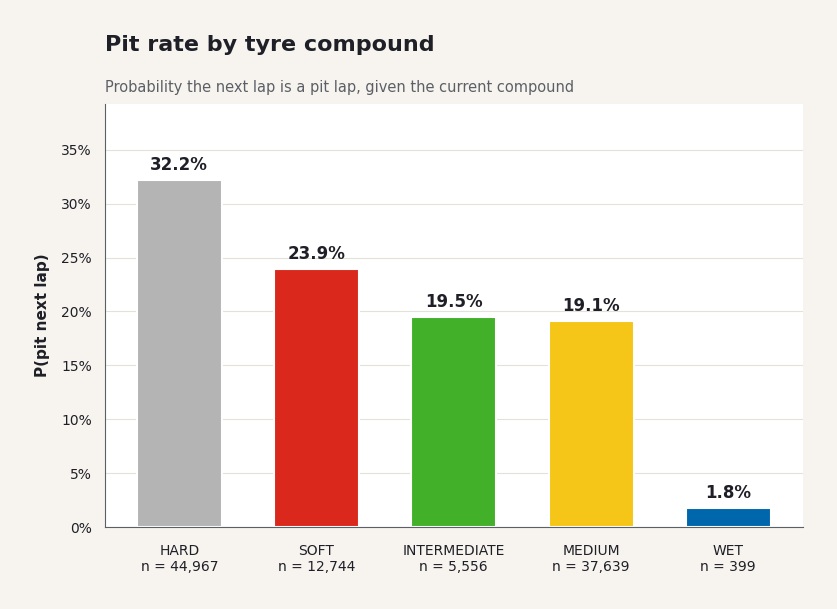

Saved: /Users/hiba/Documents/Projects/Experiments/Race Strategist/reports/figures/pit_rate_by_compound.png


In [15]:
fig, ax = plt.subplots(figsize=(9, 5.5))
order   = by_compound.index.tolist()
values  = by_compound["pit_rate"].values
colors  = [COMPOUND_COLORS.get(c, COLORS["slate"]) for c in order]
xlabels = [f"{c}\nn = {n:,}" for c, n in zip(order, by_compound["laps"].values)]

bars = ax.bar(order, values, color=colors, width=0.62,
              edgecolor="white", linewidth=1.5)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v + values.max() * 0.018,
            f"{v:.1%}", ha="center", va="bottom",
            fontsize=12, fontweight="bold", color=COLORS["charcoal"])

ax.set_title("Pit rate by tyre compound")
add_subtitle(ax, "Probability the next lap is a pit lap, given the current compound")
ax.set_ylabel("P(pit next lap)")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(xlabels)
ax.set_ylim(0, values.max() * 1.22)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax.yaxis.grid(True); ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.tick_params(axis="x", pad=6)

out = FIG_DIR / "pit_rate_by_compound.png"
fig.savefig(out)
plt.show()
print("Saved:", out)


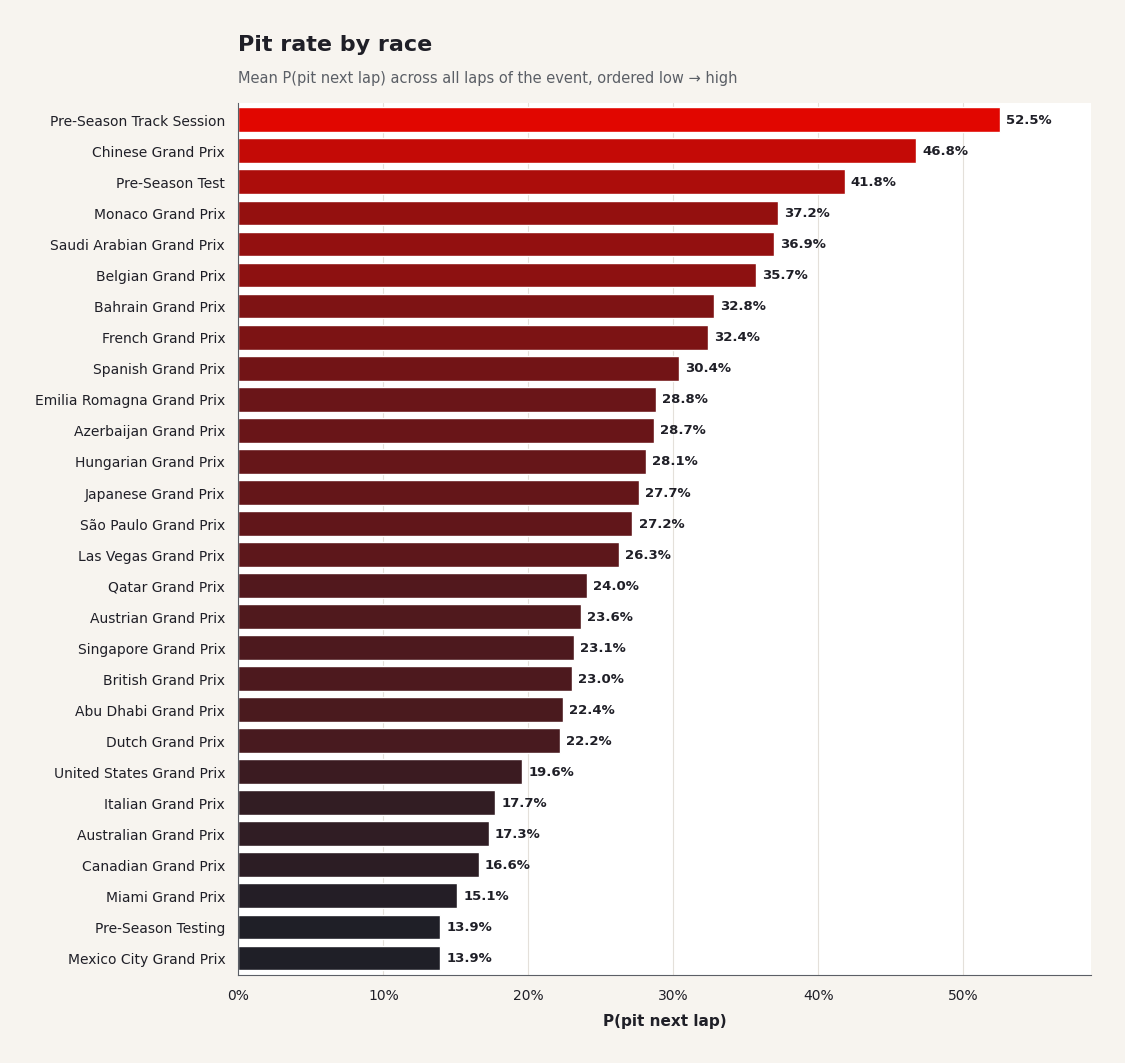

Saved: /Users/hiba/Documents/Projects/Experiments/Race Strategist/reports/figures/pit_rate_by_race.png


In [16]:
data   = by_race.sort_values("pit_rate", ascending=True)
values = data["pit_rate"].values
cmap   = mpl.colors.LinearSegmentedColormap.from_list(
    "f1_reds", [COLORS["charcoal"], COLORS["red"]])
norm   = mpl.colors.Normalize(vmin=values.min(), vmax=values.max())
colors = [cmap(norm(v)) for v in values]

fig, ax = plt.subplots(figsize=(11, 0.34 * len(data) + 1.8))
bars = ax.barh(data.index, values, color=colors,
               edgecolor="white", linewidth=1.0)

for b, v in zip(bars, values):
    ax.text(v + values.max() * 0.008, b.get_y() + b.get_height() / 2,
            f"{v:.1%}", va="center", ha="left",
            fontsize=9.5, color=COLORS["charcoal"], fontweight="semibold")

ax.set_title("Pit rate by race")
add_subtitle(ax, "Mean P(pit next lap) across all laps of the event, ordered low → high")
ax.set_xlabel("P(pit next lap)")
ax.set_xlim(0, values.max() * 1.12)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax.xaxis.grid(True); ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.margins(y=0.005)

out = FIG_DIR / "pit_rate_by_race.png"
fig.savefig(out)
plt.show()
print("Saved:", out)


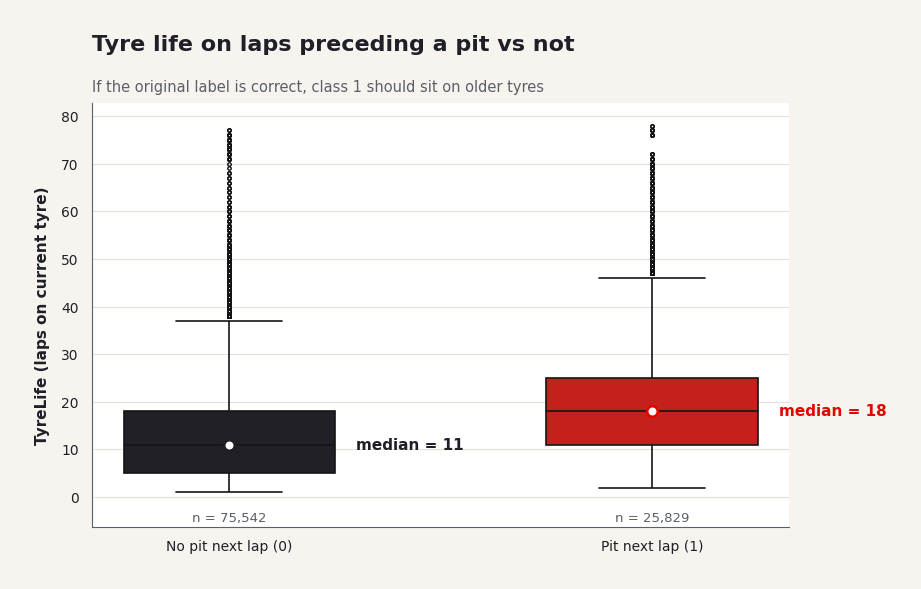

Saved: /Users/hiba/Documents/Projects/Experiments/Race Strategist/reports/figures/tyrelife_by_pitnextlap.png


In [17]:
fig, ax = plt.subplots(figsize=(9, 5.5))
palette = {0: COLORS["charcoal"], 1: COLORS["red"]}
sns.boxplot(data=df, x="PitNextLap", y="TyreLife", hue="PitNextLap",
            palette=palette, legend=False,
            width=0.50, linewidth=1.2, fliersize=2.5, ax=ax)

stats = df.groupby("PitNextLap")["TyreLife"].agg(["median", "count"])
ymax = df["TyreLife"].max()
for i, (med, n) in enumerate(stats[["median", "count"]].values):
    color = palette[i]
    ax.scatter([i], [med], s=60, color="white", edgecolor=color,
               linewidth=2.0, zorder=5)
    ax.text(i + 0.30, med, f"median = {int(med)}", va="center", ha="left",
            fontsize=11, fontweight="bold", color=color)
    ax.text(i, -ymax * 0.04, f"n = {int(n):,}", ha="center", va="top",
            fontsize=9.5, color=COLORS["slate"])

ax.set_title("Tyre life on laps preceding a pit vs not")
add_subtitle(ax, "If the original label is correct, class 1 should sit on older tyres")
ax.set_xticks([0, 1])
ax.set_xticklabels(["No pit next lap (0)", "Pit next lap (1)"])
ax.set_xlabel("")
ax.set_ylabel("TyreLife (laps on current tyre)")
ax.set_ylim(-ymax * 0.08, ymax * 1.06)
ax.yaxis.grid(True); ax.xaxis.grid(False)
ax.set_axisbelow(True)

out = FIG_DIR / "tyrelife_by_pitnextlap.png"
fig.savefig(out)
plt.show()
print("Saved:", out)


## 3. Reconstruct a Cleaner Target `WillPitNextLap`

In [18]:
df = df.sort_values(["Year", "Race", "Driver", "LapNumber"]).reset_index(drop=True)
df["NextStint"] = df.groupby(["Year", "Race", "Driver"])["Stint"].shift(-1)
df["WillPitNextLap"] = (df["NextStint"] > df["Stint"]).astype(int)

n_final_lap = int(df["NextStint"].isna().sum())
n_groups    = df.groupby(["Year", "Race", "Driver"]).ngroups
final_lap_labels = df.loc[df["NextStint"].isna(), "WillPitNextLap"].value_counts().to_dict()

print(f"Driver-race groups            : {n_groups:,}")
print(f"Final-lap rows (NextStint NaN): {n_final_lap:,}")
print(f"Label distribution on those   : {final_lap_labels}")


Driver-race groups            : 1,848
Final-lap rows (NextStint NaN): 1,848
Label distribution on those   : {0: 1848}


In [19]:
df[["Year", "Race", "Driver", "LapNumber", "Stint", "NextStint",
    "PitStop", "PitNextLap", "WillPitNextLap"]].head(12)


,Year,Race,Driver,LapNumber,Stint,NextStint,PitStop,PitNextLap,WillPitNextLap
0,2022,Australian Grand Prix,ALB,1,1,1.0,0,0,0
1,2022,Australian Grand Prix,ALB,2,1,1.0,0,0,0
2,2022,Australian Grand Prix,ALB,3,1,1.0,0,0,0
3,2022,Australian Grand Prix,ALB,4,1,1.0,0,0,0
4,2022,Australian Grand Prix,ALB,5,1,1.0,0,0,0
5,2022,Australian Grand Prix,ALB,6,1,1.0,0,0,0
6,2022,Australian Grand Prix,ALB,7,1,1.0,0,0,0
7,2022,Australian Grand Prix,ALB,8,1,1.0,0,0,0
8,2022,Australian Grand Prix,ALB,9,1,1.0,0,0,0
9,2022,Australian Grand Prix,ALB,10,1,1.0,0,0,0


## 4. Compare `PitNextLap` vs `WillPitNextLap`

In [20]:
def target_stats(s, name):
    pos = int((s == 1).sum())
    neg = int((s == 0).sum())
    return {
        "Metric": ["Positive Count", "Negative Count", "Positive Rate", "Missing Values"],
        name: [pos, neg, f"{pos / (pos + neg):.4%}" if (pos + neg) else "n/a",
               int(s.isna().sum())],
    }

a = target_stats(df["PitNextLap"], "PitNextLap")
b = target_stats(df["WillPitNextLap"], "WillPitNextLap")
comparison = pd.DataFrame({"Metric": a["Metric"],
                           "PitNextLap": a["PitNextLap"],
                           "WillPitNextLap": b["WillPitNextLap"]})
comparison


,Metric,PitNextLap,WillPitNextLap
0,Positive Count,25829,3271
1,Negative Count,75542,98100
2,Positive Rate,25.4797%,3.2268%
3,Missing Values,0,0


In [21]:
match    = int((df["PitNextLap"] == df["WillPitNextLap"]).sum())
mismatch = int((df["PitNextLap"] != df["WillPitNextLap"]).sum())
total    = len(df)
match_pct = match / total

print(f"Total rows  : {total:,}")
print(f"Matches     : {match:,}")
print(f"Mismatches  : {mismatch:,}")
print(f"Match rate  : {match_pct:.4%}")
print()
print("Confusion matrix (rows = PitNextLap, cols = WillPitNextLap):")
cm = pd.crosstab(df["PitNextLap"], df["WillPitNextLap"],
                 rownames=["PitNextLap"], colnames=["WillPitNextLap"])
print(cm)


Total rows  : 101,371
Matches     : 75,547
Mismatches  : 25,824
Match rate  : 74.5253%

Confusion matrix (rows = PitNextLap, cols = WillPitNextLap):
WillPitNextLap      0     1
PitNextLap                 
0               73909  1633
1               24191  1638


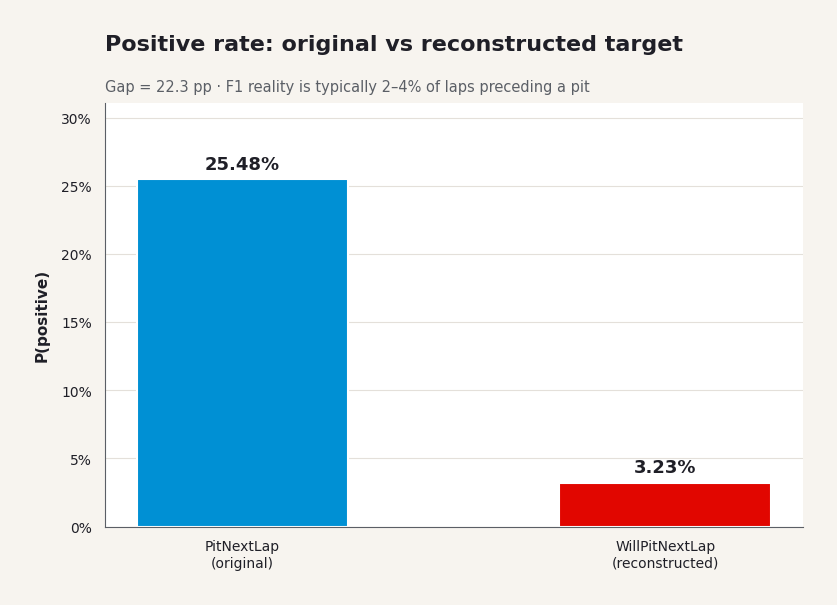

Saved: /Users/hiba/Documents/Projects/Experiments/Race Strategist/reports/figures/target_positive_rate_comparison.png


In [22]:
labels = ["PitNextLap\n(original)", "WillPitNextLap\n(reconstructed)"]
rates  = [(df["PitNextLap"] == 1).mean(),
          (df["WillPitNextLap"] == 1).mean()]
colors = [COLORS["accent"], COLORS["red"]]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(labels, rates, color=colors, width=0.5,
              edgecolor="white", linewidth=1.5)
for b, v in zip(bars, rates):
    ax.text(b.get_x() + b.get_width() / 2, v + max(rates) * 0.018,
            f"{v:.2%}", ha="center", va="bottom",
            fontsize=13, fontweight="bold", color=COLORS["charcoal"])

ax.set_title("Positive rate: original vs reconstructed target")
add_subtitle(ax,
    f"Gap = {abs(rates[0] - rates[1]) * 100:.1f} pp · "
    "F1 reality is typically 2–4% of laps preceding a pit")
ax.set_ylabel("P(positive)")
ax.set_ylim(0, max(rates) * 1.22)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax.yaxis.grid(True); ax.xaxis.grid(False)
ax.set_axisbelow(True)

out = FIG_DIR / "target_positive_rate_comparison.png"
fig.savefig(out)
plt.show()
print("Saved:", out)


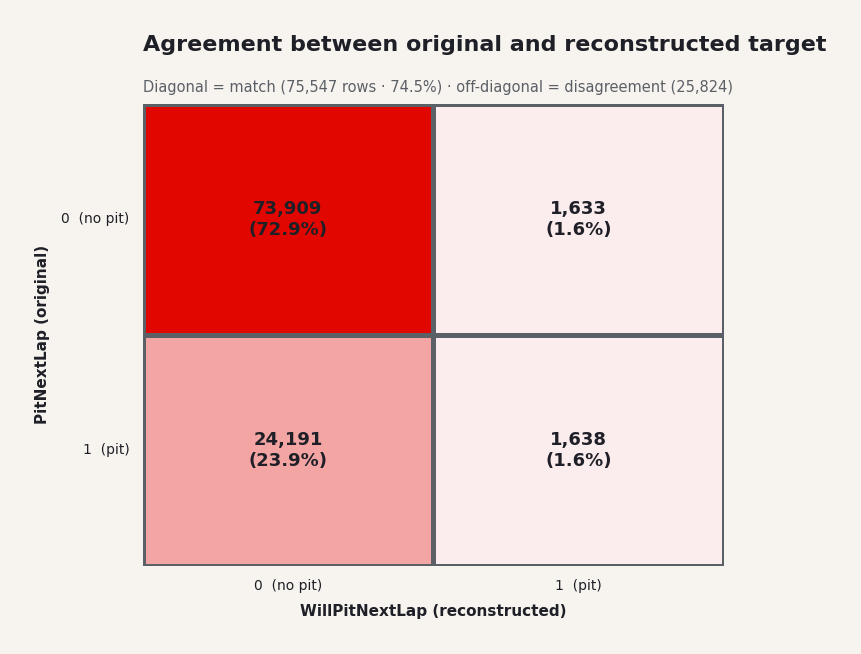

Saved: /Users/hiba/Documents/Projects/Experiments/Race Strategist/reports/figures/target_confusion_matrix.png


In [23]:
fig, ax = plt.subplots(figsize=(7.5, 6))
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "f1_heat", ["#FBEDED", COLORS["red"]])

cm_pct = cm / cm.values.sum()
annot  = cm.copy().astype(object)
for r in cm.index:
    for c in cm.columns:
        annot.loc[r, c] = f"{cm.loc[r, c]:,}\n({cm_pct.loc[r, c]:.1%})"

sns.heatmap(cm, annot=annot, fmt="", cmap=cmap, cbar=False,
            linewidths=2.5, linecolor=COLORS["slate"],
            annot_kws={"fontsize": 13, "fontweight": "bold",
                       "color": COLORS["charcoal"]},
            ax=ax)
ax.set_title("Agreement between original and reconstructed target")
add_subtitle(ax,
    f"Diagonal = match ({match:,} rows · {match_pct:.1%}) · "
    f"off-diagonal = disagreement ({mismatch:,})")
ax.set_xlabel("WillPitNextLap (reconstructed)")
ax.set_ylabel("PitNextLap (original)")
ax.set_xticklabels(["0  (no pit)", "1  (pit)"], rotation=0)
ax.set_yticklabels(["0  (no pit)", "1  (pit)"], rotation=0)

out = FIG_DIR / "target_confusion_matrix.png"
fig.savefig(out)
plt.show()
print("Saved:", out)


## 5. Investigate Mismatched Rows

In [24]:
mismatches = df[df["PitNextLap"] != df["WillPitNextLap"]].copy()
print("Mismatched rows:", len(mismatches))
print()
mismatches[["Year", "Race", "Driver", "LapNumber", "Stint", "NextStint",
            "PitStop", "PitNextLap", "WillPitNextLap",
            "Compound", "TyreLife", "RaceProgress"]].head(20)


Mismatched rows: 25824



,Year,Race,Driver,LapNumber,Stint,NextStint,PitStop,PitNextLap,WillPitNextLap,Compound,TyreLife,RaceProgress
95,2022,Australian Grand Prix,ALO,39,1,2.0,0,0,1,HARD,39.0,0.541667
109,2022,Australian Grand Prix,ALO,53,2,3.0,0,0,1,MEDIUM,14.0,0.736111
135,2022,Australian Grand Prix,BOT,22,1,2.0,0,0,1,MEDIUM,22.0,0.314286
191,2022,Australian Grand Prix,GAS,21,1,2.0,0,0,1,MEDIUM,21.0,0.291667
249,2022,Australian Grand Prix,HAM,22,1,2.0,1,0,1,MEDIUM,22.0,0.305556
297,2022,Australian Grand Prix,LAT,13,1,2.0,0,0,1,MEDIUM,13.0,0.183099
303,2022,Australian Grand Prix,LAT,19,2,2.0,0,1,0,HARD,7.0,0.267606
304,2022,Australian Grand Prix,LAT,20,2,2.0,0,1,0,HARD,8.0,0.281690
305,2022,Australian Grand Prix,LAT,21,2,2.0,0,1,0,HARD,9.0,0.295775
306,2022,Australian Grand Prix,LAT,22,2,2.0,0,1,0,HARD,10.0,0.309859


In [25]:
mismatches["is_final_lap"] = mismatches["NextStint"].isna()

print("Mismatches by final-lap status:")
print(mismatches["is_final_lap"].value_counts())
print()
print("Mismatch direction (PitNextLap vs WillPitNextLap):")
print(pd.crosstab(mismatches["PitNextLap"], mismatches["WillPitNextLap"],
                  rownames=["PitNextLap"], colnames=["WillPitNextLap"]))
print()
print("Top 10 races by mismatch count:")
print(mismatches.groupby("Race").size().sort_values(ascending=False).head(10))
print()
print("Mismatch count by compound:")
print(mismatches.groupby("Compound").size().sort_values(ascending=False))


Mismatches by final-lap status:
is_final_lap
False    24994
True       830
Name: count, dtype: int64

Mismatch direction (PitNextLap vs WillPitNextLap):
WillPitNextLap      0     1
PitNextLap                 
0                   0  1633
1               24191     0

Top 10 races by mismatch count:
Race
Monaco Grand Prix            1917
Hungarian Grand Prix         1476
Spanish Grand Prix           1476
Bahrain Grand Prix           1401
Saudi Arabian Grand Prix     1276
Dutch Grand Prix             1201
Austrian Grand Prix          1160
Belgian Grand Prix           1119
Emilia Romagna Grand Prix    1075
Azerbaijan Grand Prix        1061
dtype: int64

Mismatch count by compound:
Compound
HARD            14198
MEDIUM           7410
SOFT             2981
INTERMEDIATE     1158
WET                39
dtype: int64


## 6. Recommend the Final Target

In [26]:
pn_pos_rate = (df["PitNextLap"] == 1).mean()
wp_pos_rate = (df["WillPitNextLap"] == 1).mean()
rate_gap_pp = abs(pn_pos_rate - wp_pos_rate) * 100

final_lap_mismatches = int(((df["PitNextLap"] != df["WillPitNextLap"]) &
                            (df["NextStint"].isna())).sum())
other_mismatches     = mismatch - final_lap_mismatches
final_lap_share      = final_lap_mismatches / mismatch if mismatch else 0.0

if match_pct >= 0.99 and rate_gap_pp <= 0.2:
    decision = "USE_ORIGINAL"
elif final_lap_share >= 0.5:
    decision = "USE_RECONSTRUCTED"
else:
    decision = "USE_RECONSTRUCTED"

print(f"Match rate                         : {match_pct:.4%}")
print(f"Positive rate gap (PN vs Will), pp : {rate_gap_pp:.3f}")
print(f"Mismatches total                   : {mismatch:,}")
print(f"  - on final lap of a driver-race  : {final_lap_mismatches:,}  ({final_lap_share:.1%})")
print(f"  - elsewhere                      : {other_mismatches:,}")
print()
print("Recommendation:", decision)


Match rate                         : 74.5253%
Positive rate gap (PN vs Will), pp : 22.253
Mismatches total                   : 25,824
  - on final lap of a driver-race  : 830  (3.2%)
  - elsewhere                      : 24,994

Recommendation: USE_RECONSTRUCTED


## 7. Save the Validated Dataset

In [27]:
original_cols = [c for c in df.columns if c not in ("NextStint", "WillPitNextLap")]
out_df = df[original_cols + ["NextStint", "WillPitNextLap"]]

out_df.to_csv(OUT_DATA_PATH, index=False)
print("Wrote:", OUT_DATA_PATH)
print("Shape:", out_df.shape)
print("Columns:", out_df.columns.tolist())
out_df.head()


Wrote: /Users/hiba/Documents/Projects/Experiments/Race Strategist/data/f1_strategy_dataset_v4_validated.csv
Shape: (101371, 18)
Columns: ['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change', 'NextStint', 'WillPitNextLap']


,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change,NextStint,WillPitNextLap
0,ALB,1,HARD,1,1.0,20,101.690,Australian Grand Prix,2022,-3.333,-7.446,0,0,0.013889,0.017544,-5.0,1.0,0
1,ALB,2,HARD,1,2.0,19,89.169,Australian Grand Prix,2022,-9.960,27.730,0,0,0.027778,0.035088,-4.0,1.0,0
2,ALB,3,HARD,1,3.0,18,115.834,Australian Grand Prix,2022,17.974,45.782,0,0,0.041667,0.052632,-3.0,1.0,0
3,ALB,4,HARD,1,4.0,18,132.047,Australian Grand Prix,2022,33.783,84.152,0,0,0.055556,0.070175,-3.0,1.0,0
4,ALB,5,HARD,1,5.0,18,137.043,Australian Grand Prix,2022,37.900,111.357,0,0,0.069444,0.087719,-2.0,1.0,0
